In [1]:
!pip -q install aif360 shap reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.6 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
!pip -q install aif360
!pip -q install fairlearn
!pip -q install inFairness
!pip -q install shap
!pip -q install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 49.3 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import shap

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing

In [6]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
df.replace("?", np.nan, inplace=True)

df.dropna(inplace=True)

print("After removing missing values:")

print(df.shape)

After removing missing values:
(45222, 15)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             45222 non-null  int64   
 1   workclass       45222 non-null  category
 2   fnlwgt          45222 non-null  int64   
 3   education       45222 non-null  category
 4   education-num   45222 non-null  int64   
 5   marital-status  45222 non-null  category
 6   occupation      45222 non-null  category
 7   relationship    45222 non-null  category
 8   race            45222 non-null  category
 9   sex             45222 non-null  category
 10  capital-gain    45222 non-null  int64   
 11  capital-loss    45222 non-null  int64   
 12  hours-per-week  45222 non-null  int64   
 13  native-country  45222 non-null  category
 14  class           45222 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.8 MB


In [9]:
df["class"] = df["class"].astype(str)

df["class"] = np.where(df["class"] == ">50K", 1, 0)

print(df["class"].value_counts())

class
0    34014
1    11208
Name: count, dtype: int64


In [10]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object", "category"]).columns

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Encoding Completed")

df.head()

Encoding Completed


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,2,226802,1,7,4,6,3,2,1,0,0,40,38,0
1,38,2,89814,11,9,2,4,0,4,1,0,0,50,38,0
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38,1
3,44,2,160323,15,10,2,6,0,2,1,7688,0,40,38,1
5,34,2,198693,0,6,4,7,1,4,1,0,0,30,38,0


In [11]:
X = df.drop("class", axis=1)

y = df["class"]

print(X.shape)

print(y.shape)

(45222, 14)
(45222,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (36177, 14)
Testing Data  : (9045, 14)


In [13]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [14]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", round(accuracy, 4))

print("\nClassification Report\n")

print(classification_report(y_test, predictions))

Accuracy : 0.8028

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      6803
           1       0.67      0.40      0.50      2242

    accuracy                           0.80      9045
   macro avg       0.75      0.67      0.69      9045
weighted avg       0.79      0.80      0.78      9045



In [15]:
fairness_df = df.copy()

dataset = BinaryLabelDataset(
    df=fairness_df,
    label_names=["class"],
    protected_attribute_names=["sex"],
    favorable_label=1,
    unfavorable_label=0
)

metric = BinaryLabelDatasetMetric(
    dataset,
    privileged_groups=[{"sex": 1}],
    unprivileged_groups=[{"sex": 0}]
)

print("Disparate Impact :", round(metric.disparate_impact(), 4))
print("Mean Difference  :", round(metric.mean_difference(), 4))

Disparate Impact : 0.3635
Mean Difference  : -0.1989


In [16]:
rw = Reweighing(
    privileged_groups=[{"sex": 1}],
    unprivileged_groups=[{"sex": 0}]
)

rw.fit(dataset)

dataset_transformed = rw.transform(dataset)

print("Reweighing Applied Successfully")

Reweighing Applied Successfully


In [17]:
metric_after = BinaryLabelDatasetMetric(
    dataset_transformed,
    privileged_groups=[{"sex": 1}],
    unprivileged_groups=[{"sex": 0}]
)

print("Disparate Impact Before :", round(metric.disparate_impact(), 4))
print("Disparate Impact After  :", round(metric_after.disparate_impact(), 4))

print()

print("Mean Difference Before :", round(metric.mean_difference(), 4))
print("Mean Difference After  :", round(metric_after.mean_difference(), 4))

Disparate Impact Before : 0.3635
Disparate Impact After  : 1.0

Mean Difference Before : -0.1989
Mean Difference After  : 0.0


In [20]:
import shap
import warnings

# Hide Python warnings
warnings.filterwarnings("ignore")

# Use only 100 background samples explicitly
background = shap.sample(X_train, 100, random_state=42)

# Create explainer
explainer = shap.LinearExplainer(model, background)

# Generate SHAP values
shap_values = explainer(X_test)

print("SHAP values generated successfully.")

SHAP values generated successfully.


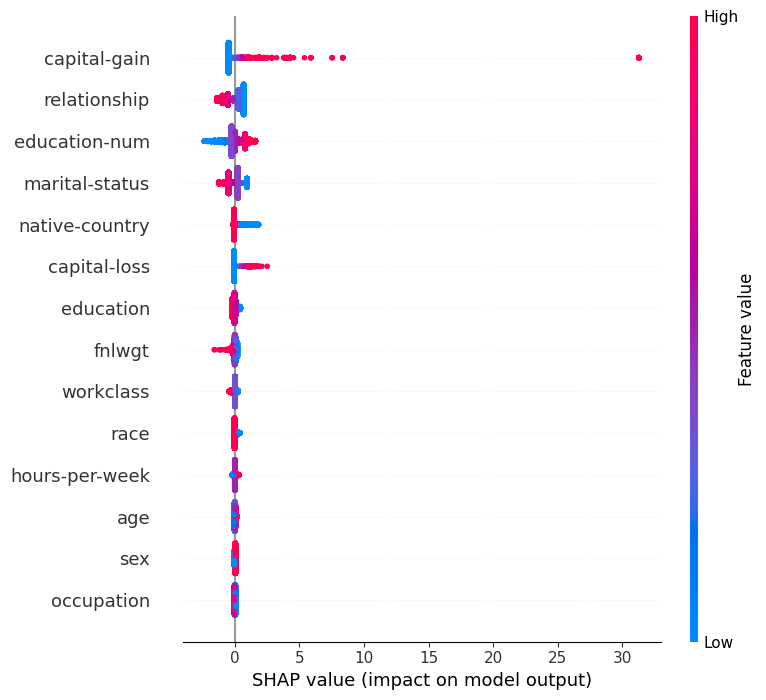

In [21]:
plt.figure(figsize=(10,6))

shap.plots.beeswarm(shap_values, max_display=14, show=False)

plt.tight_layout()

plt.show()

SHAP Summary Plot Saved


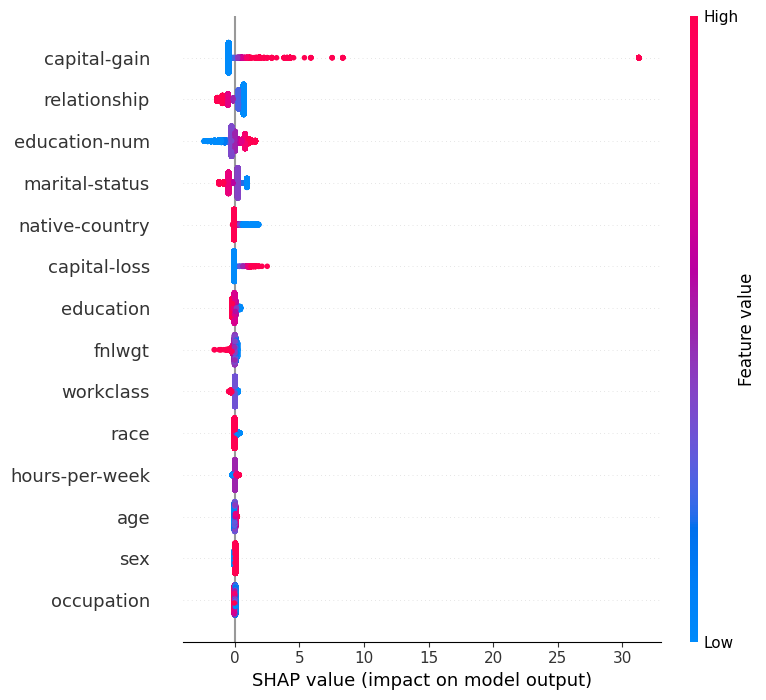

In [22]:
plt.figure(figsize=(10,6))

shap.plots.beeswarm(shap_values, max_display=14, show=False)

plt.tight_layout()

plt.savefig("shap_summary.png", dpi=300)

print("SHAP Summary Plot Saved")

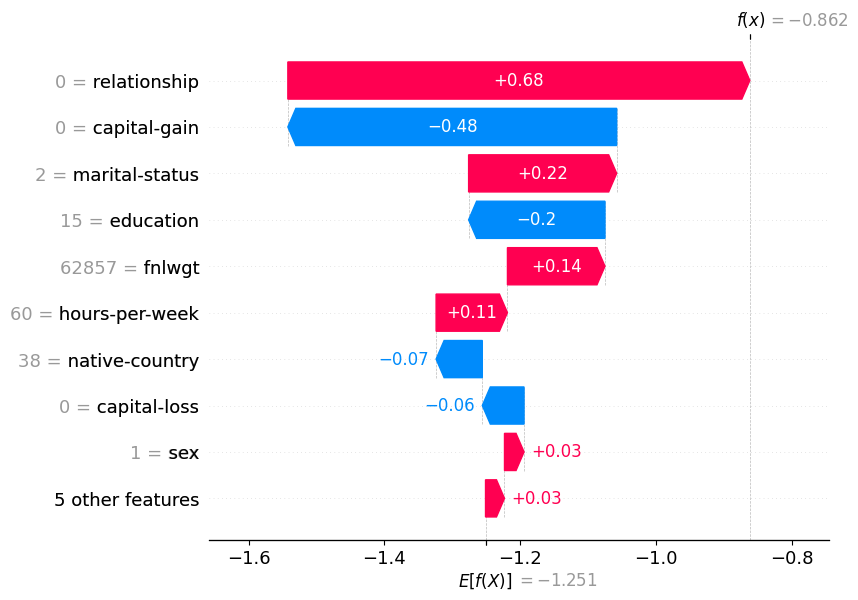

In [23]:
shap.plots.waterfall(shap_values[0])

In [24]:
plt.savefig("shap_waterfall.png", dpi=300)

print("Waterfall Plot Saved")

Waterfall Plot Saved


<Figure size 640x480 with 0 Axes>

In [25]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("model_card.pdf")

story = []

story.append(Paragraph("<b>MODEL CARD</b>", styles["Heading1"]))

story.append(Paragraph("<b>Model Details</b>", styles["Heading2"]))
story.append(Paragraph("Model Name: Logistic Regression", styles["BodyText"]))
story.append(Paragraph("Framework: Scikit-learn", styles["BodyText"]))

story.append(Paragraph("<b>Intended Use</b>", styles["Heading2"]))
story.append(Paragraph("Predict whether an individual's annual income is greater than $50K using demographic and employment information.", styles["BodyText"]))

story.append(Paragraph("<b>Training Data</b>", styles["Heading2"]))
story.append(Paragraph("UCI Adult Income Dataset", styles["BodyText"]))

story.append(Paragraph("<b>Evaluation Metrics</b>", styles["Heading2"]))
story.append(Paragraph(f"Accuracy: {accuracy:.4f}", styles["BodyText"]))

story.append(Paragraph("<b>Fairness Analysis</b>", styles["Heading2"]))
story.append(Paragraph(f"Disparate Impact (Before): {metric.disparate_impact():.4f}", styles["BodyText"]))
story.append(Paragraph(f"Disparate Impact (After): {metric_after.disparate_impact():.4f}", styles["BodyText"]))

story.append(Paragraph("<b>Protected Attribute</b>", styles["Heading2"]))
story.append(Paragraph("Gender (sex)", styles["BodyText"]))

story.append(Paragraph("<b>Ethical Considerations</b>", styles["Heading2"]))
story.append(Paragraph("The model should support decision-making rather than replace human judgment. Regular fairness monitoring and bias mitigation are recommended.", styles["BodyText"]))

story.append(Paragraph("<b>Limitations</b>", styles["Heading2"]))
story.append(Paragraph("The dataset contains historical information that may not fully represent today's population or workforce.", styles["BodyText"]))

doc.build(story)

print("✅ model_card.pdf created successfully")

✅ model_card.pdf created successfully


In [26]:
from reportlab.platypus import SimpleDocTemplate, Paragraph
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()

doc = SimpleDocTemplate("india_ai_bias_case_analysis.pdf")

story = []

story.append(Paragraph("<b>AI Bias Case in India</b>", styles["Heading1"]))

analysis = """
Facial recognition systems used for identity verification in India have raised concerns about bias.
Studies have shown that these systems may perform less accurately for individuals with darker skin
tones due to representation bias in the training data. If the training dataset contains fewer
examples of diverse skin tones, the model may incorrectly identify or reject some users.

Another contributing factor is measurement bias caused by differences in lighting conditions,
camera quality, and image capture environments. These issues can reduce recognition accuracy and
affect fairness in real-world applications.

To reduce bias, organizations should use balanced datasets representing India's diverse population,
perform regular fairness audits using metrics such as disparate impact and equalized odds, apply
bias mitigation techniques like reweighing, and continuously monitor model performance after
deployment. Explainability tools such as SHAP can also improve transparency and accountability.
"""

story.append(Paragraph(analysis, styles["BodyText"]))

doc.build(story)

print("✅ india_ai_bias_case_analysis.pdf created successfully")

✅ india_ai_bias_case_analysis.pdf created successfully


In [27]:
from google.colab import files

files.download("model_card.pdf")
files.download("india_ai_bias_case_analysis.pdf")
files.download("shap_summary.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>